# SISA Random Forest : Leaf Influence Unlearning
**Dataset:** Iowa recidivism + injected COMPAS rows with **Model:** RF SISA

Scoring is based on leaf influence, increase the score of datapoints that fall into leaves who vote positive for Black non-recidivists


## 1. Imports & Configuration

In [15]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler


CSV_PATH = 'combined_adapted_with_counts.csv'
SEED = 42
NUM_SHARDS = 15 #SISA number of shards (Can affect fpr of baselines and after retrainning)
NUM_SLICES = 10 #SISA number of slices (doesn't matter much for RF)
THRESHOLD = 0.57 #Classification threshold
TARGET_RACE = 'Black'
NUM_EXAMPLES_TO_REMOVE =  500 #Number of datapoints to remove
OUT = 'results/'
CHECKPOINT_DIR = 'checkpoints_rf' #Save Model check Points

os.makedirs(OUT, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

np.random.seed(SEED)

MODEL_COLORS = {
    'Baseline (No Unlearning)' : '#ff7f0e',
    'SISA RF (Unlearned)'      : '#9467bd',
}
print(f'Config : Shards={NUM_SHARDS} | Threshold={THRESHOLD} | Remove={NUM_EXAMPLES_TO_REMOVE}')


Config : Shards=15 | Threshold=0.57 | Remove=500


## 2. Load & Encode Data

In [16]:
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]
if 'source' in df.columns: df = df.drop(columns=['source'])

TARGET = 'recidivism'
CAT_COLS = ['race', 'age_cat', 'offense_classification', 'offense_type']
NUM_COLS = ['priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count']
race_col = df['race'].values #Useful for tracking bias

#Concatenating numerical and categorical features
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype='float32')
X_cat = ohe.fit_transform(df[CAT_COLS].astype(str))
scaler = StandardScaler()
X_num = scaler.fit_transform(df[NUM_COLS]).astype('float32')
X = np.concatenate([X_cat, X_num], axis=1).astype('float32')
y = df[TARGET].values.astype('float32')

(X_tr, X_test, y_tr, y_test,
 race_tr, race_test, idx_tr, idx_test) = train_test_split(
    X, y, race_col, np.arange(len(df)),
    test_size=0.2, random_state=SEED, stratify=y)

print(f'Data : Rows={len(df)} | Recidivism rate={y.mean():.3f} | Features={X.shape[1]}')
print(f'Train={X_tr.shape} | Test={X_test.shape}')


Data : Rows=33199 | Recidivism rate=0.359 | Features=20
Train=(26559, 20) | Test=(6640, 20)


## 3. SISA Helpers

In [ ]:
# The SISA file won't be used since we're not using neural networks



def create_shards(X, y, race, global_idx, num_shards, seed=42):
    ''' Randomly divides the training set into num_shards non-overlapping subsets '''
    perm = np.random.RandomState(seed).permutation(len(X))
    return [dict(X=X[sp], y=y[sp], race=race[sp],
                 local_indices=sp,
                 global_indices=global_idx[sp])  # Original df row numbers
            for sp in np.array_split(perm, num_shards)]


def create_slices(shard, num_slices):
    '''
    Split a shard into ordered num_slices ordered, non-overlapping subsets.
    Each slice is a dict with the same keys as a shard.
    '''
    n = len(shard['X'])
    # np.array_split gives roughly equal chunks; last may be 1 row smaller
    splits = np.array_split(np.arange(n), num_slices)
    return [dict(X=shard['X'][idx],
                 y=shard['y'][idx],
                 race=shard['race'][idx],
                 local_indices=shard['local_indices'][idx],
                 global_indices=shard['global_indices'][idx])
            for idx in splits]


def train_rf(X, y):
    ''' Fit a single Random Forest classifier '''
    rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                                 class_weight='balanced',  # handles class imbalance
                                 random_state=SEED, n_jobs=-1)
    rf.fit(X, y)
    return rf


def train_sisa(X, y, race, global_idx, num_shards, num_slices):
    '''
    Full SISA training with slicing and checkpointing.
    For each shard:
      1. Split the shard into num_slices ordered slices
      2. Train cumulatively: on slice 0, then slices 0+1, then 0+1+2, etc.
      3. Save a checkpoint after each cumulative slice
    '''
    shards = create_shards(X, y, race, global_idx, num_shards, seed=SEED)
    models = {}
    all_slices = []

    for sid, shard in enumerate(shards):
        slices = create_slices(shard, num_slices)
        all_slices.append(slices)

        # Train cumulatively: each checkpoint covers slices 0..i
        for i in range(num_slices):
            # Stack all data from slices 0 to i inclusive
            X_cum = np.concatenate([sl['X'] for sl in slices[:i+1]])
            y_cum = np.concatenate([sl['y'] for sl in slices[:i+1]])

            model = train_rf(X_cum, y_cum)

            # Save checkpoint after this cumulative slice
            ckpt_path = f'{CHECKPOINT_DIR}/shard{sid}_slice{i}.pkl'
            with open(ckpt_path, 'wb') as f:pickle.dump(model, f)

        # The final model (trained on all slices) is the live model
        models[sid] = model
        print(f'  Shard {sid}: trained on {num_slices} slices | {len(shard["X"])} examples | checkpoints are saved')
    return models, shards, all_slices


def unlearn_sisa(baseline_shards, all_slices, remove_per_shard):
    '''
    SISA unlearning with checkpoints.

    For each affected shard:
      1. Find the earliest slice that contains a point to remove
      2. Load the checkpoint from just before that slice
         NOTE: For RF, loading the checkpoint does NOT resume training
         RF trees cannot be updated incrementally. The shard is always retrained from
         scratch on all slices minus the removed points.
         NOTE: The bug was only noticed after the presentation, but will be included in the report
      3. Retrain from start_slice onward, removing points only from their slice
      4. Unaffected shards are loaded directly from their final checkpoint

    For clarification:

    Parameters
    ---
    baseline_shards: list of shard dicts (from train_sisa)
    all_slices: list of lists of slice dicts (from train_sisa)
    remove_per_shard : dict {shard_id -> set of local_positions to remove}

    Returns
    ---
    unlearned_models : dict {shard_id -> retrained or unchanged RF}
    '''
    unlearned_models = {}

    for sid, shard in enumerate(baseline_shards):
        slices = all_slices[sid]

        if sid not in remove_per_shard:
            # Shard untouched: loads its final checkpoint
            ckpt_path = f'{CHECKPOINT_DIR}/shard{sid}_slice{NUM_SLICES-1}.pkl'
            with open(ckpt_path, 'rb') as f: unlearned_models[sid] = pickle.load(f)
            print(f'  Shard {sid}: unchanged (loaded from checkpoint)')
            continue

        removed_lpos = remove_per_shard[sid]  # set of local positions to exclude

        # Find earliest slice containing a point to remove
        # removed_lpos are 0..n positions within the shard
        # each slice covers a consecutive range of those positions
        start_slice = NUM_SLICES  # just initializing
        slice_start = 0
        for slice_id, sl in enumerate(slices):
            slice_end = slice_start + len(sl['X'])
            # Check if any removed position falls within this slice's range
            if removed_lpos & set(range(slice_start, slice_end)):
                start_slice = slice_id
                break
            slice_start = slice_end

        # Load checkpoint from just before start_slice
        # NOTE: For RF this checkpoint cannot be used to resume training
        # it is loaded for reference only. RF always retrains from scratch below.
        if start_slice > 0:
            ckpt_path = f'{CHECKPOINT_DIR}/shard{sid}_slice{start_slice-1}.pkl'
            with open(ckpt_path, 'rb') as f: model = pickle.load(f)  # not resumable for RF
            print(f'  Shard {sid}: forget set in slice {start_slice} (checkpoint shard{sid}_slice{start_slice-1} loaded)')
        else:  # Just to prevent error
            model = None
            print(f'  Shard {sid}: forget set in slice 0, retraining from scratch')

        # Slices before start_slice are clean
        # Removed points are filtered only from the slice they belong to
        for i in range(start_slice, NUM_SLICES):
            # Clean Slices
            X_parts = [slices[j]['X'] for j in range(start_slice)]
            y_parts = [slices[j]['y'] for j in range(start_slice)]

            # Remove datapoints per slice
            # Track running position offset to map each slice to shard-level positions
            pos_offset = sum(len(slices[k]['X']) for k in range(start_slice))
            for j in range(start_slice, i + 1):
                slice_len = len(slices[j]['X'])
                # Positions of this slice within the shard (0..n)
                slice_positions = range(pos_offset, pos_offset + slice_len)
                keep_mask = np.array([pos not in removed_lpos for pos in slice_positions])
                X_parts.append(slices[j]['X'][keep_mask])
                y_parts.append(slices[j]['y'][keep_mask])
                pos_offset += slice_len

            X_cum = np.concatenate(X_parts)
            y_cum = np.concatenate(y_parts)

            if len(X_cum) == 0:
                print(f'    Warning: shard {sid} slice {i} empty after removal, skipping')
                continue

            model = train_rf(X_cum, y_cum)

            # Save updated checkpoint after each cumulative slice
            ckpt_path = f'{CHECKPOINT_DIR}/shard{sid}_slice{i}_unlearned.pkl'
            with open(ckpt_path, 'wb') as f: pickle.dump(model, f)

        n_removed = len(removed_lpos)
        n_retrained = len(shard['X']) - n_removed
        print(f'    Removed {n_removed} points | retrained on {n_retrained} examples | forget set was in slice {start_slice}')
        unlearned_models[sid] = model

    return unlearned_models


def ensemble_proba(models, X):
    ''' Average predicted positive-class probability across all shard models '''
    return np.mean([models[sid].predict_proba(X)[:, 1]
                    for sid in range(NUM_SHARDS) if sid in models], axis=0)


def ensemble_predict(models, X, threshold=THRESHOLD):
    ''' Hard binary prediction from ensemble average probability '''
    return (ensemble_proba(models, X) >= threshold).astype(int)


def compute_bias(y_true, y_pred, race_labels):
    ''' Compute FPR, FNR, and accuracy for each race group '''
    out = {}
    for race in sorted(set(race_labels)):
        mask = race_labels == race
        if mask.sum() < 3: continue
        yt, yp = y_true[mask].astype(int), y_pred[mask].astype(int)
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
        out[race] = dict(n=int(mask.sum()),
                         accuracy=float(accuracy_score(yt, yp)),
                         FPR=fp/(fp+tn) if (fp+tn)>0 else 0.0,
                         FNR=fn/(fn+tp) if (fn+tp)>0 else 0.0)
    return out


def collapse_bias(bias_dict):
    ''' Pool all races except Black and White into a single Other category '''
    out = {k: bias_dict[k] for k in ('Black','White') if k in bias_dict}
    others = {r: m for r, m in bias_dict.items() if r not in ('Black','White')}
    if others:
        n = sum(m['n'] for m in others.values())
        out['Other'] = dict(n=n,
            accuracy=sum(m['accuracy']*m['n'] for m in others.values())/n,
            FPR=sum(m['FPR']*m['n']      for m in others.values())/n,
            FNR=sum(m['FNR']*m['n']      for m in others.values())/n)
    return out


print('SISA helpers defined')


SISA helpers defined


## 4. Train Baseline SISA

In [18]:
# Train all shards — each split into NUM_SLICES and checkpointed after every slice
t0 = time.time()
baseline_models, baseline_shards, all_slices = train_sisa(
    X_tr, y_tr, race_tr, idx_tr, NUM_SHARDS, NUM_SLICES)
t_rf_train = time.time() - t0

n_checkpoints = NUM_SHARDS * NUM_SLICES
print(f'\nBaseline trained in {t_rf_train}s')
print(f'  {NUM_SHARDS} shards × {NUM_SLICES} slices = {n_checkpoints} checkpoints saved')
print(f'  ~{len(X_tr)//NUM_SHARDS} examples per shard | ~{len(X_tr)//(NUM_SHARDS*NUM_SLICES)} per slice')
print(f'  Checkpoints saved to: {CHECKPOINT_DIR}/')


  Shard 0: trained on 10 slices | 1771 examples | checkpoints are saved
  Shard 1: trained on 10 slices | 1771 examples | checkpoints are saved
  Shard 2: trained on 10 slices | 1771 examples | checkpoints are saved
  Shard 3: trained on 10 slices | 1771 examples | checkpoints are saved
  Shard 4: trained on 10 slices | 1771 examples | checkpoints are saved
  Shard 5: trained on 10 slices | 1771 examples | checkpoints are saved
  Shard 6: trained on 10 slices | 1771 examples | checkpoints are saved
  Shard 7: trained on 10 slices | 1771 examples | checkpoints are saved
  Shard 8: trained on 10 slices | 1771 examples | checkpoints are saved
  Shard 9: trained on 10 slices | 1770 examples | checkpoints are saved
  Shard 10: trained on 10 slices | 1770 examples | checkpoints are saved
  Shard 11: trained on 10 slices | 1770 examples | checkpoints are saved
  Shard 12: trained on 10 slices | 1770 examples | checkpoints are saved
  Shard 13: trained on 10 slices | 1770 examples | checkpoint

## 5. Leaf-Based Influence Scoring
Each training point is scored by how much it causes Black test non-recidivists
to be falsely predicted positive via shared positive-voting leaves.

```
influence(i) = (1/T) Σ_t  vote(leaf_t(i)) × n_probe_in_leaf_t(i)
```
Only positive-voting leaves that contain probe examples contribute.

In [19]:
def compute_leaf_influence(rf_model, X_shard, X_probe):
    ''' 
    Score each training point by how much it causes Black non-recidivists (X_probe) 
    to be falsely predicted positive via shared positive-voting leaves.

    '''
    n_train = len(X_shard)
    n_probe = len(X_probe)
    if n_probe == 0: # No probe examples
        return np.zeros(n_train)

    train_leaves = rf_model.apply(X_shard)   # Leaf id of each trainning point per tree
    probe_leaves = rf_model.apply(X_probe)   # Leaf id of each probe point per tree
    influence = np.zeros(n_train)

    for t_idx, tree in enumerate(rf_model.estimators_):
        tl = train_leaves[:, t_idx]  # ID For the specific tree
        pl = probe_leaves[:, t_idx]
        tree_proba = tree.predict_proba(X_shard)[:, 1]  # keep positive class proba for each point

        # Count how many probe examples land in each leaf
        probe_leaf_count = {}
        for leaf in pl:
            probe_leaf_count[leaf] = probe_leaf_count.get(leaf, 0) + 1
        active = set(probe_leaf_count)  # leaves that contain at least one probe example

        # Vote strength of each active leaf
        leaf_vote = {leaf: tree_proba[tl == leaf][0]
                     for leaf in active if (tl == leaf).any()}

        # Score each training point: only contributes if its leaf is active and votes positive
        for i in range(n_train):
            leaf = tl[i]
            vote = leaf_vote.get(leaf, 0.0)
            if leaf in active and vote >= 0.5:
                influence[i] += vote * probe_leaf_count[leaf]  # higher vote + more probe examples = higher influence

    return influence / len(rf_model.estimators_)  # average

print('Compute_leaf_influence defined')


Compute_leaf_influence defined


In [20]:
# Probe = Black non-recidivists from test set
probe_mask = (race_test == TARGET_RACE) & (y_test == 0)
X_probe = X_test[probe_mask]
print(f'Probe set: {len(X_probe)} {TARGET_RACE} non-recidivists')
print('Scoring shards...')

all_scores = []
for sid, shard in enumerate(baseline_shards):
    infl = compute_leaf_influence(baseline_models[sid], shard['X'], X_probe)
    for lpos, score in enumerate(infl):
        all_scores.append((sid, lpos, score)) #Shard position and score
    n_nz = int((infl > 0).sum())
    print(f'  Shard {sid}: {n_nz} non-zero | max={infl.max():.2f} mean={infl[infl>0].mean():.2f}')

all_scores.sort(key=lambda x: x[2], reverse=True)
top_candidates = all_scores[:NUM_EXAMPLES_TO_REMOVE] #The top scores

removed_labels = [baseline_shards[s]['y'][l]    for s,l,_ in top_candidates]
print(f'Labels: pos={int(sum(removed_labels))} neg={NUM_EXAMPLES_TO_REMOVE-int(sum(removed_labels))}')


Probe set: 1172 Black non-recidivists
Scoring shards...
  Shard 0: 1707 non-zero | max=72.73 mean=12.29
  Shard 1: 1694 non-zero | max=74.29 mean=13.89
  Shard 2: 1708 non-zero | max=79.17 mean=19.58
  Shard 3: 1731 non-zero | max=103.27 mean=22.68
  Shard 4: 1694 non-zero | max=73.55 mean=15.60
  Shard 5: 1771 non-zero | max=70.58 mean=18.53
  Shard 6: 1751 non-zero | max=92.24 mean=17.60
  Shard 7: 1735 non-zero | max=97.60 mean=24.49
  Shard 8: 1733 non-zero | max=59.18 mean=17.06
  Shard 9: 1673 non-zero | max=58.74 mean=14.95
  Shard 10: 1677 non-zero | max=81.65 mean=23.66
  Shard 11: 1696 non-zero | max=78.94 mean=18.38
  Shard 12: 1727 non-zero | max=70.71 mean=16.50
  Shard 13: 1657 non-zero | max=56.64 mean=14.73
  Shard 14: 1700 non-zero | max=64.94 mean=14.01
Labels: pos=226 neg=274


## 6. Unlearning : Retrain Affected Shards

In [21]:
# Group removed candidates by shard ID
remove_per_shard = {}
for sid, lpos, _ in top_candidates:
    remove_per_shard.setdefault(sid, set()).add(lpos)

shards_affected = len(remove_per_shard)
print(f'Unlearning {NUM_EXAMPLES_TO_REMOVE} points across '
      f'{shards_affected}/{NUM_SHARDS} shards...\n')

t0 = time.time()
unlearned_models = unlearn_sisa(baseline_shards, all_slices, remove_per_shard)
t_rf_unlearn = time.time() - t0

print(f'\n Unlearning done in {t_rf_unlearn:.2f}s')
print(f'  Shards retrained : {shards_affected} / {NUM_SHARDS}')
print(f'  Shards unchanged : {NUM_SHARDS - shards_affected} / {NUM_SHARDS}')


Unlearning 500 points across 11/15 shards...

  Shard 0: forget set in slice 0, retraining from scratch
    Removed 12 points | retrained on 1759 examples | forget set was in slice 0
  Shard 1: forget set in slice 0, retraining from scratch
    Removed 27 points | retrained on 1744 examples | forget set was in slice 0
  Shard 2: forget set in slice 0, retraining from scratch
    Removed 38 points | retrained on 1733 examples | forget set was in slice 0
  Shard 3: forget set in slice 0, retraining from scratch
    Removed 134 points | retrained on 1637 examples | forget set was in slice 0
  Shard 4: forget set in slice 0, retraining from scratch
    Removed 26 points | retrained on 1745 examples | forget set was in slice 0
  Shard 5: forget set in slice 0, retraining from scratch
    Removed 12 points | retrained on 1759 examples | forget set was in slice 0
  Shard 6: forget set in slice 0, retraining from scratch
    Removed 18 points | retrained on 1753 examples | forget set was in sl

## 7. Evaluation

In [ ]:
baseline_pred = ensemble_predict(baseline_models,  X_test)
baseline_prob = ensemble_proba(baseline_models,    X_test)
unlearned_pred = ensemble_predict(unlearned_models, X_test)
unlearned_prob = ensemble_proba(unlearned_models,   X_test)

baseline_bias = compute_bias(y_test, baseline_pred,  race_test)
unlearned_bias = compute_bias(y_test, unlearned_pred, race_test)

b_base = baseline_bias.get(TARGET_RACE, {}).get('FPR', float('nan'))
b_unl = unlearned_bias.get(TARGET_RACE,{}).get('FPR', float('nan'))
w_base = baseline_bias.get('White', {}).get('FPR', float('nan'))
w_unl = unlearned_bias.get('White', {}).get('FPR', float('nan'))
delta = b_unl - b_base

print('\n' + '='*62 + '\nEVALUATION\n' + '='*62)

for label, pred, prob, bias in [
    ('Baseline',  baseline_pred,  baseline_prob,  baseline_bias),
    ('Unlearned', unlearned_pred, unlearned_prob, unlearned_bias),
]:
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    print(f'\n{label}: Acc={acc:.2f} AUC={auc:.2f}')
    for race, m in sorted(bias.items()):
        print(f'  {race:12s}: FPR={m["FPR"]:.2f}  FNR={m["FNR"]:.2f}  acc={m["accuracy"]:.2f}')

print(f'\n--> {TARGET_RACE} FPR: {b_base:.2f} --> {b_unl:.2f}   Δ={delta:+.2f}'
      f' ({" improved" if delta < 0 else "worsened"})')
print(f'  Bias gap: {b_base-w_base:+.2f} --> {b_unl-w_unl:+.2f}')



EVALUATION

Baseline: Acc=0.64 AUC=0.60
  Asian       : FPR=0.00  FNR=1.00  acc=0.81
  Black       : FPR=0.15  FNR=0.78  acc=0.59
  Hispanic    : FPR=0.00  FNR=1.00  acc=0.74
  Native American: FPR=0.00  FNR=0.98  acc=0.50
  Other       : FPR=0.02  FNR=1.00  acc=0.62
  White       : FPR=0.01  FNR=0.98  acc=0.66

Unlearned: Acc=0.64 AUC=0.60
  Asian       : FPR=0.00  FNR=1.00  acc=0.81
  Black       : FPR=0.12  FNR=0.81  acc=0.60
  Hispanic    : FPR=0.00  FNR=1.00  acc=0.74
  Native American: FPR=0.00  FNR=0.98  acc=0.50
  Other       : FPR=0.02  FNR=1.00  acc=0.62
  White       : FPR=0.01  FNR=0.98  acc=0.66

→ Black FPR: 0.15 → 0.12   Δ=-0.03 (↓ improved)
  Bias gap: +0.14 → +0.10


## 8. Speed Comparison : SISA vs Full RF Retrain
- **Full RF** = **2 × t_train**
- **SISA RF** = **t_sisa + t_unlearn**


In [23]:
print('Timing full single RF train...')
t0 = time.time()
full_rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                                 class_weight='balanced',
                                 random_state=SEED, n_jobs=-1)
full_rf.fit(X_tr, y_tr)
t_full_rf = time.time() - t0

full_pred = (full_rf.predict_proba(X_test)[:, 1] >= THRESHOLD).astype(int)
full_prob = full_rf.predict_proba(X_test)[:, 1]
full_bias = compute_bias(y_test, full_pred, race_test)
fpr_full = full_bias.get(TARGET_RACE, {}).get('FPR', float('nan'))

t_full_total = 2 * t_full_rf              # original train + corrected retrain
t_sisa_total = t_rf_train + t_rf_unlearn  # SISA train + unlearn affected shards

print(f'\n Full RF single train: {t_full_rf:.2f}s | Black FPR={fpr_full:.2f}')
print(f'\n{"="*62}\nTOTAL COST (train + fix)\n{"="*62}')
print(f'  Full RF   : {t_full_rf:.2f}s × 2 = {t_full_total:.2f}s')
print(f'  SISA RF   : {t_rf_train:.2f}s + {t_rf_unlearn:.2f}s = {t_sisa_total:.2f}s')
print(f'\nFAIRNESS')
print(f'  Baseline SISA  : Black FPR={b_base:.2f}')
print(f'  Full RF train: Black FPR={fpr_full:.2f}')
print(f'  SISA unlearned : Black FPR={b_unl:.2f}  (Δ={delta:+.2f})')


Timing full single RF train...

 Full RF single train: 0.14s | Black FPR=0.24

TOTAL COST (train + fix)
  Full RF   : 0.14s × 2 = 0.29s
  SISA RF   : 11.70s + 7.80s = 19.50s

FAIRNESS
  Baseline SISA  : Black FPR=0.15
  Full RF train: Black FPR=0.24
  SISA unlearned : Black FPR=0.12  (Δ=-0.03)


## 9. Visualizations

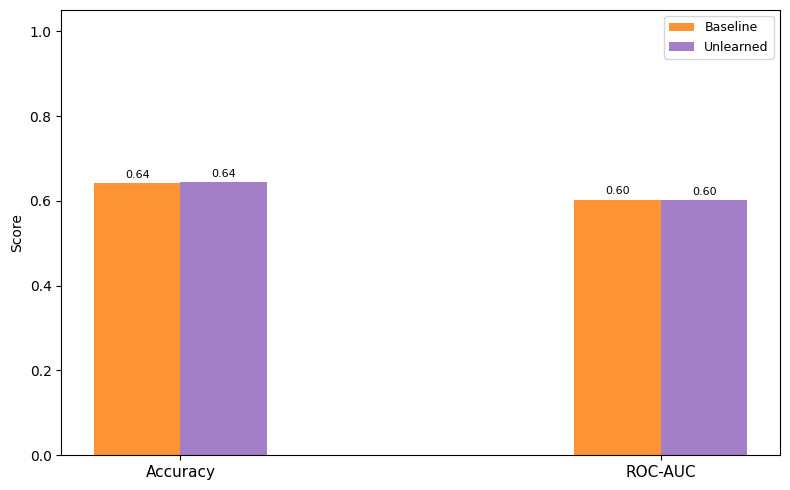

In [24]:
def save_fig(name):
    plt.tight_layout()
    plt.savefig(OUT + name, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

def label_bars(ax, bars, fmt='{:.2f}', offset=0.008):
    for bar in bars:
        v = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, v + offset,
                fmt.format(v), ha='center', va='bottom', fontsize=8)

b_fig = collapse_bias(baseline_bias)
u_fig = collapse_bias(unlearned_bias)
all_bias_fig = {'Baseline': b_fig, 'Unlearned': u_fig}
all_metrics_fig = { 'Baseline':  dict(accuracy=accuracy_score(y_test, baseline_pred),  auc=roc_auc_score(y_test, baseline_prob)),
                    'Unlearned': dict(accuracy=accuracy_score(y_test, unlearned_pred), auc=roc_auc_score(y_test, unlearned_prob)),
}
races_fig = [r for r in ['Black', 'White', 'Other'] if any(r in b for b in all_bias_fig.values())]
colors = list(MODEL_COLORS.values())
model_names = list(all_bias_fig.keys())

# Fig 1: Accuracy & AUC
fig, ax = plt.subplots(figsize=(8, 5))
x, w = np.arange(2), 0.18
for i, mn in enumerate(model_names):
    vals = [all_metrics_fig[mn]['accuracy'], all_metrics_fig[mn]['auc']]
    label_bars(ax, ax.bar(x + i*w, vals, w, label=mn, color=colors[i], alpha=0.85), '{:.2f}')
ax.set_xticks(x + w/2); ax.set_xticklabels(['Accuracy', 'ROC-AUC'], fontsize=11)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score'); ax.legend(fontsize=9)
save_fig('fig_rf_overall.png')



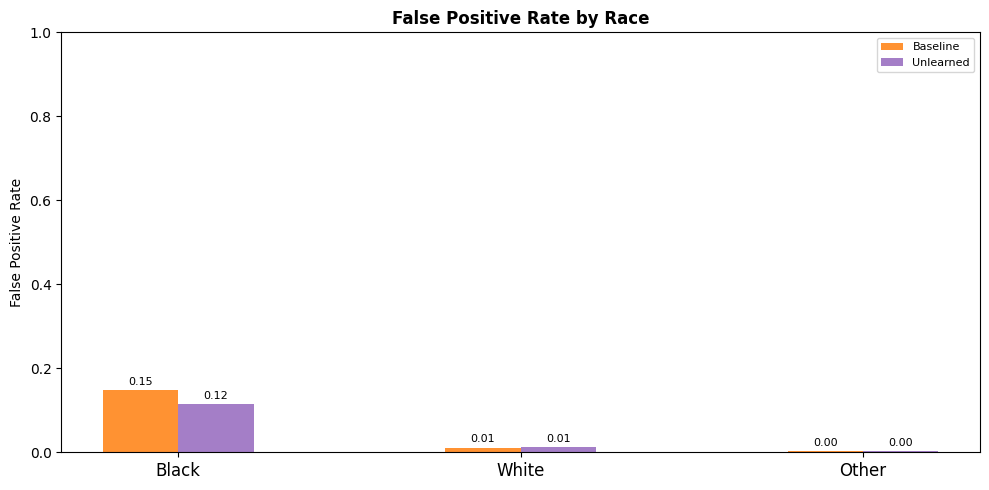

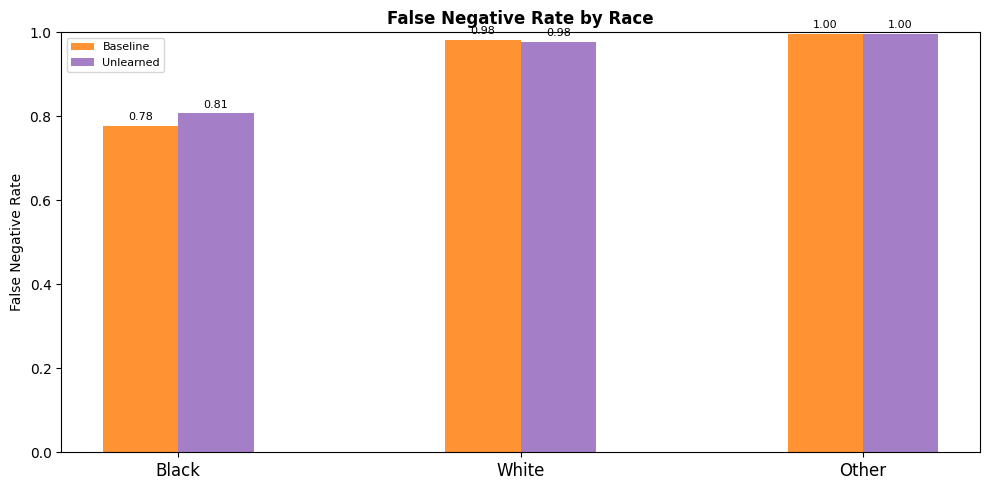

In [25]:
# Figs 2-3: FPR and FNR by race
for key, ylabel, fname in [
    ('FPR', 'False Positive Rate', 'fig_rf_fpr.png'),
    ('FNR', 'False Negative Rate', 'fig_rf_fnr.png'),
]:
    fig, ax = plt.subplots(figsize=(10, 5))
    x, w = np.arange(len(races_fig)), 0.22
    for i, mn in enumerate(model_names):
        vals = [all_bias_fig[mn].get(r, {}).get(key, 0) for r in races_fig]
        label_bars(ax, ax.bar(x + i*w, vals, w, label=mn, color=colors[i], alpha=0.85))
    ax.set_xticks(x + w/2); ax.set_xticklabels(races_fig, fontsize=12)
    ax.set_ylabel(ylabel); ax.set_ylim(0, 1.0); ax.legend(fontsize=8)
    ax.set_title(f'{ylabel} by Race', fontsize=12, fontweight='bold')
    save_fig(fname)

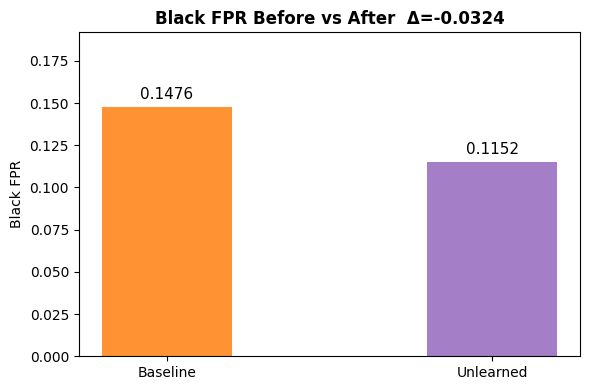

In [26]:
# Fig 4: Black FPR before vs after
fig, ax = plt.subplots(figsize=(6, 4))
for bar, v in zip(ax.bar(['Baseline', 'Unlearned'], [b_base, b_unl], color=['#ff7f0e', '#9467bd'], width=0.4, alpha=0.85), [b_base, b_unl]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{v:.4f}', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Black FPR'); ax.set_ylim(0, max(b_base, b_unl) * 1.3)
ax.set_title(f'Black FPR Before vs After  Δ={delta:+.4f}', fontsize=12, fontweight='bold')
save_fig('fig_rf_black_fpr.png')

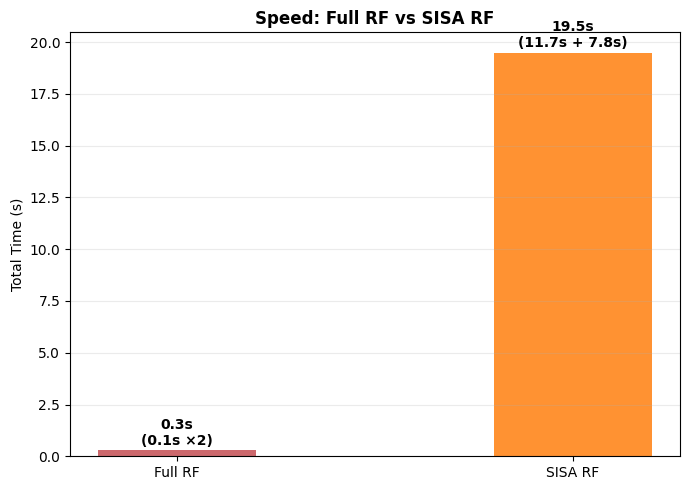

All figures saved to results/


In [27]:
# Fig 5: Speed comparison
fig, ax = plt.subplots(figsize=(7, 5))
for bar, v, lbl in zip(
    ax.bar(['Full RF', 'SISA RF'], [t_full_total, t_sisa_total],  color=['#C44E52', '#ff7f0e'], alpha=0.85, width=0.4),
    [t_full_total, t_sisa_total],
    [f'{t_full_rf:.1f}s ×2', f'{t_rf_train:.1f}s + {t_rf_unlearn:.1f}s']
):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{v:.1f}s\n({lbl})', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Total Time (s)'); ax.set_title('Speed: Full RF vs SISA RF', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
save_fig('fig_rf_speed.png')

print('All figures saved to', OUT)